## Credit Card Fraud Detection — Notebook

This notebook follows the official requirements in `docs/ASSIGNMENT_REQUIREMENTS.md` and is written to emphasize **critical reasoning** and **business-aware evaluation**.

---

## Part 1 — Goals of the Project

### Problem formulation
Credit card fraud detection is modeled as a **binary classification** task:
- **Target** `Class = 1`: fraudulent transaction
- **Target** `Class = 0`: legitimate transaction

The practical aim is to **flag suspicious transactions** early to reduce financial losses and reputational damage.

### Why accuracy is misleading here
The dataset is extremely imbalanced: only **492 frauds out of 284,807 transactions** (fraud prevalence ~**0.172%**). In such a setting, a classifier that predicts *always legitimate* would reach ~**99.828%** accuracy while being **useless** (it would miss every fraud). This is the classic **accuracy paradox**.

### Optimization objective (business-aware)
For fraud detection, the cost of **false negatives** (missed fraud) is typically high. Therefore, our primary objective is to:
- **maximize Recall** on the fraud class (reduce missed frauds), and
- **maximize PR-AUC (AUPRC)**, which is more informative than ROC-AUC under extreme imbalance.

We will still monitor precision and use threshold-aware analysis, because increasing recall often increases false positives (customer friction and operational review cost).

---

## Part 2 — Data Presentation and Description

### Dataset context and scope
Transactions were made by European cardholders in **September 2013** and cover **two days** of activity.

### Dataset structure
- **Rows**: 284,807 transactions
- **Columns**: 31 features in total (including the target)

### Feature meaning
- `V1`–`V28`: **PCA components** (original features are not provided for confidentiality)
- `Time`: seconds elapsed from the first transaction in the dataset
- `Amount`: transaction amount (relevant for cost-sensitive reasoning)
- `Class`: target label (`1` fraud, `0` legitimate)

Because `Time` and `Amount` are not PCA-transformed, they may require **dedicated preprocessing** (e.g., robust scaling) to avoid disproportionate influence and to handle skew/outliers.


### Setup: import libraries and configure the environment

In this cell we import the core libraries used throughout the notebook.

**Why this matters**: a fixed and explicit import block improves reproducibility and makes it clear which tools are used for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

**Expected output**: no tabular output; at most a one-time Matplotlib message while it builds the font cache.


In [17]:
import os

# Make Matplotlib cache writable even in restricted environments
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".cache", "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility (plots and any sampling later)
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")


### Load the dataset (`creditcard.csv`)

In this cell we load the dataset from a **relative path**.

**Why this matters**: using a deterministic path and a clear error message prevents silent failures and makes the notebook runnable by a marker.

**Expected output**: a confirmation message that the file exists and the dataset has been loaded.


In [18]:
DATA_PATH = "creditcard.csv"  # stored in project root (intentionally ignored by git)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Expected it in the same folder as main.ipynb."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded dataset from:", os.path.abspath(DATA_PATH))

Loaded dataset from: /Users/stefan/Desktop/Farm/Git_hub/Lisa_project/Lisa_project/creditcard.csv


### Verify dataset structure (rows/columns) and preview the first rows

We confirm the dataset shape and column names to ensure we are working with the expected schema (31 columns including `Class`).

**Why this matters**: this is a traceability check against the dataset description and helps catch issues such as wrong files, wrong separators, or corrupted downloads.

**Expected output**: printed shape, printed list of columns, and a small preview (`head`).


In [19]:
print("Dataset shape (rows, cols):", df.shape)
print("Number of columns:", df.shape[1])
print("\nColumns:")
print(df.columns.to_list())

display(df.head())

Dataset shape (rows, cols): (284807, 31)
Number of columns: 31

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Check for missing values (nulls)

The official dataset description states there are **no missing values**. We verify this claim explicitly.

**Why this matters**: if missing values were present, we would need an imputation strategy (which could bias results under imbalance). Proving absence of nulls removes a common confound early.

**Expected output**: total count of missing values (should be 0). If not 0, a table of columns with missing values.


In [20]:
null_counts = df.isna().sum()
null_total = int(null_counts.sum())

print("Total null values in dataset:", null_total)
if null_total == 0:
    print("No missing values detected.")
else:
    print("Missing values per column (non-zero):")
    display(null_counts[null_counts > 0].sort_values(ascending=False))

Total null values in dataset: 0
No missing values detected.


### Quantify class imbalance and compute a naive baseline

We quantify the number of frauds vs legitimate transactions and compute the **majority-class baseline accuracy** (always predicting legitimate).

**Why this matters**: this baseline demonstrates the **accuracy paradox** in a concrete way and motivates the choice of **PR-AUC** and **recall-focused** evaluation.

**Expected output**: counts, class rates (percentages), fraud prevalence, and baseline accuracy.


In [21]:
assert "Class" in df.columns, "Target column 'Class' is missing"

class_counts = df["Class"].value_counts().sort_index()
class_rates = class_counts / len(df)

print("Class distribution (counts):")
print(class_counts)
print("\nClass distribution (rates):")
print(class_rates.apply(lambda x: f"{x:.6%}"))

fraud_rate = float(class_rates.loc[1])
majority_accuracy = float(class_rates.loc[0])

print(f"\nFraud prevalence: {fraud_rate:.6%}")
print(f"Majority-class baseline accuracy (always legit): {majority_accuracy:.6%}")

Class distribution (counts):
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (rates):
Class
0    99.827251%
1     0.172749%
Name: count, dtype: str

Fraud prevalence: 0.172749%
Majority-class baseline accuracy (always legit): 99.827251%


### Descriptive statistics for `Time` and `Amount`

`Time` and `Amount` are the only non-PCA features and often have **different scale** and **heavy-tailed** distributions.

**Why this matters**: these summaries inform preprocessing choices (e.g., **RobustScaler** for `Amount`, optional transformations, and consistent scaling policies across models).

**Expected output**: `describe()` tables for `Time` and `Amount`.


In [22]:
for col in ["Time", "Amount"]:
    if col in df.columns:
        print(f"{col} summary:")
        display(df[col].describe())
        print()

Time summary:


count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


Amount summary:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

---

## Part 3 — Exploratory Data Analysis (initial)

EDA here is intentionally focused and decision-oriented. The goal is not to create many plots, but to extract a small set of **high-leverage insights** that influence the modeling pipeline.

We start by visualizing the target imbalance. This is a technical necessity because it directly determines:
- which metrics are meaningful (PR-AUC, recall vs accuracy),
- whether we need stratified splitting and imbalance-aware learning (class weights / sampling),
- and whether threshold tuning will be mandatory.


/var/folders/xz/mf35m0ds37d9_0cybdhwtcqw0000gn/T/ipykernel_23442/2676458256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Class", hue=None, palette="deep")


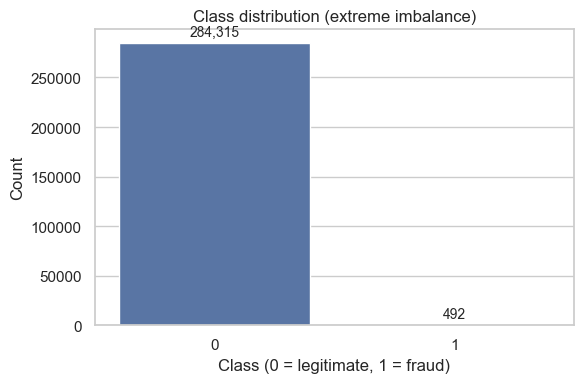

In [23]:
# Bar plot of the target variable (Class)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Class", hue=None, palette="deep")

ax.set_title("Class distribution (extreme imbalance)")
ax.set_xlabel("Class (0 = legitimate, 1 = fraud)")
ax.set_ylabel("Count")

# Annotate counts on bars for clarity
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

**Interpretation (Class imbalance)**

The plot highlights an **extreme class imbalance**: almost all transactions are legitimate (Class 0), while frauds (Class 1) are extremely rare.

**Implication**: in this setting, **accuracy** can look very high even for a useless model (e.g., always predicting 0). Therefore, evaluation should focus on **Recall** and **PR-AUC (AUPRC)** and, later on, a **threshold-aware** analysis to manage the trade-off between false positives and false negatives.


### Amount distribution by class (legit vs fraud)

`Amount` is one of the only two non-PCA features and is typically **right-skewed** with potential outliers. Comparing its distribution across classes helps answer two modeling-relevant questions:

- **Signal**: do frauds tend to happen at systematically different transaction amounts?
- **Preprocessing**: does the distribution suggest the need for a **robust scaler** (or log-transform) to limit the influence of large outliers?

Because the classes are highly imbalanced, we avoid plots dominated by the majority class by using transparency and (optionally) a log scale on the x-axis.


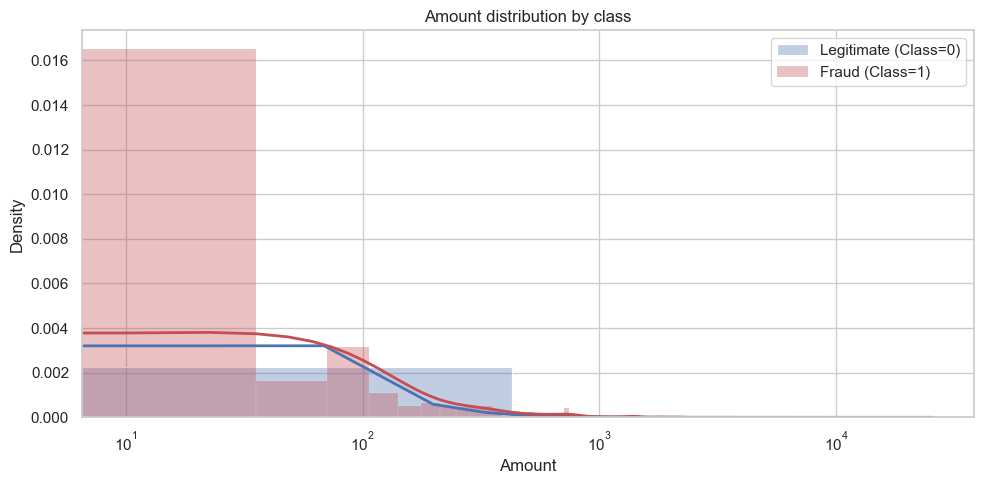

,median,p90,p99
Legitimate,22.00,202.724,1016.9664
Fraud,9.25,346.746,1357.4279


In [24]:
# Histogram/KDE of Amount by Class
# Note: KDE can be unstable for heavy tails; we combine histogram + density.

plt.figure(figsize=(10, 5))

# Split by class
amount_legit = df.loc[df["Class"] == 0, "Amount"]
amount_fraud = df.loc[df["Class"] == 1, "Amount"]

# Use common bins to make comparison fair
bins = 60

sns.histplot(amount_legit, bins=bins, stat="density", color="C0", alpha=0.35, label="Legitimate (Class=0)")
sns.histplot(amount_fraud, bins=bins, stat="density", color="C3", alpha=0.35, label="Fraud (Class=1)")

# Overlay KDE (optional but useful)
sns.kdeplot(amount_legit, color="C0", lw=2)
sns.kdeplot(amount_fraud, color="C3", lw=2)

plt.title("Amount distribution by class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

# Amount is usually heavy-tailed; log scale improves readability
plt.xscale("log")
plt.tight_layout()
plt.show()

# Quick numeric comparison (median and high quantiles are robust under skew)
summary = pd.DataFrame(
    {
        "median": [amount_legit.median(), amount_fraud.median()],
        "p90": [amount_legit.quantile(0.90), amount_fraud.quantile(0.90)],
        "p99": [amount_legit.quantile(0.99), amount_fraud.quantile(0.99)],
    },
    index=["Legitimate", "Fraud"],
)

display(summary)

**Interpretation (Amount by class)**

The `Amount` distribution is typically **right-skewed (heavy-tailed)**: many transactions have small amounts, while few have very large amounts. Comparing Class 0 vs Class 1 helps assess whether `Amount` contains **signal** (e.g., frauds being more frequent in specific amount ranges).

**Implication**: because `Amount` is not PCA-transformed, it may require **robust scaling** (e.g., `RobustScaler`) and/or transformations (e.g., log) to reduce the influence of outliers. It is also a good feature for **cost-sensitive** reasoning (false negatives on high-amount transactions imply larger potential losses).


### Correlation heatmap (feature-to-feature and feature-to-target)

A correlation heatmap provides a compact view of linear relationships. In this dataset, most predictors (`V1`–`V28`) are **PCA components**, so we typically expect:
- **low correlations among `V` features** (PCA produces orthogonal components under the transformation), and
- potentially **stronger correlations between some components and the target** `Class` (because the PCA space can still capture patterns that distinguish fraud).

This plot informs two technical decisions:
- we should not over-interpret correlation among PCA components as “real-world causality” (features are anonymized),
- but we can use feature–target correlations as a **sanity check** that the label has measurable signal and to motivate baseline linear models.


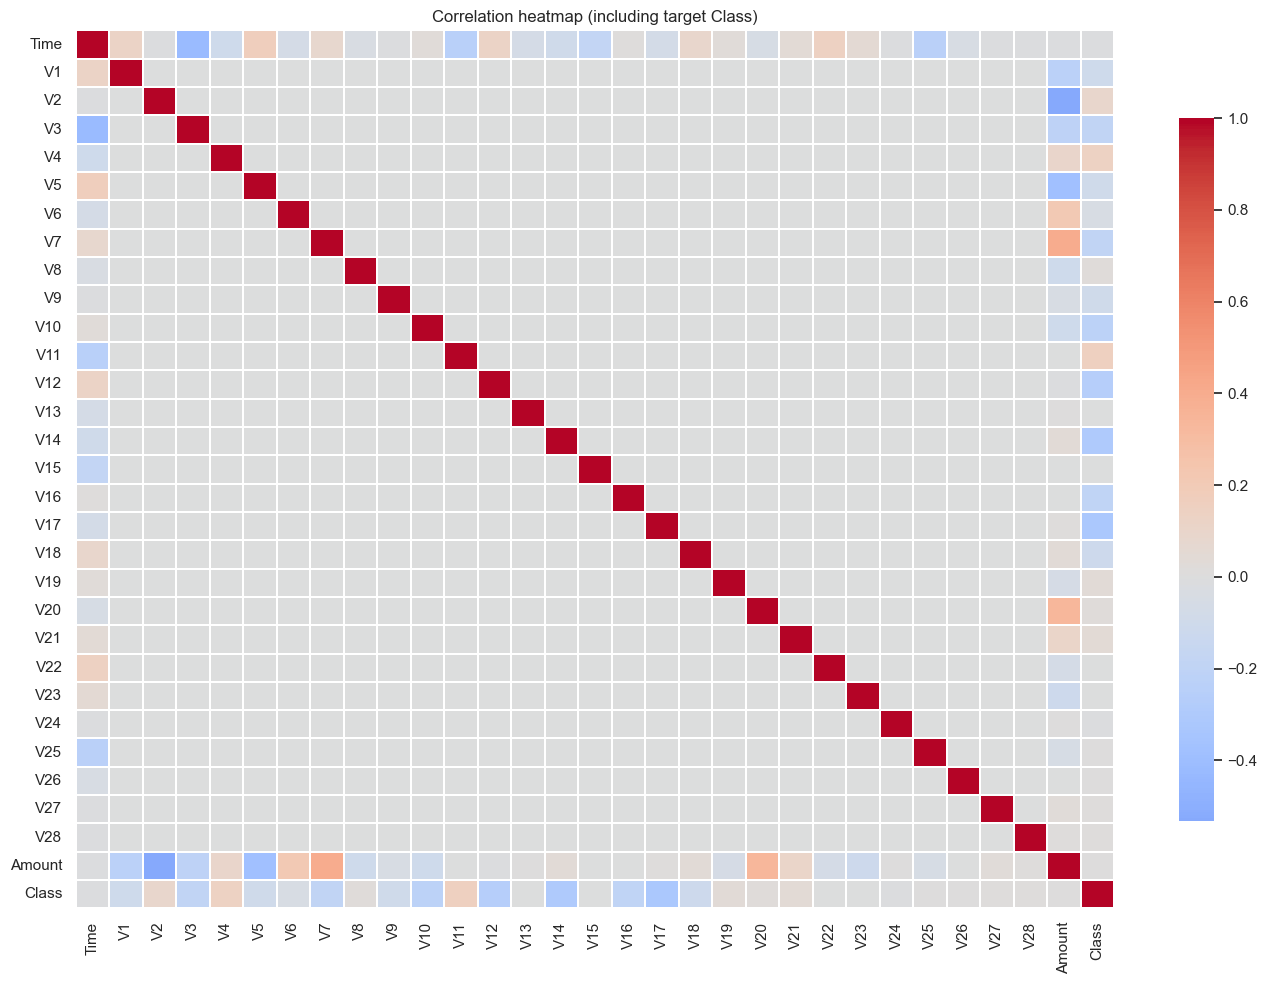

Top absolute correlations with Class (linear):


,|corr(Class)|
V17,0.326481
V14,0.302544
V12,0.260593
V10,0.216883
V16,0.196539
V3,0.192961
V7,0.187257
V11,0.154876
V4,0.133447
V18,0.111485


In [25]:
# Correlation heatmap
# We include 'Class' to see which features correlate most with the target.

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation heatmap (including target Class)")
plt.tight_layout()
plt.show()

# Show top linear correlations with the target for quick interpretability
if "Class" in corr.columns:
    top_corr = (
        corr["Class"].drop("Class").abs().sort_values(ascending=False).head(10)
    )
    print("Top absolute correlations with Class (linear):")
    display(top_corr.to_frame(name="|corr(Class)|"))

**Interpretation (Correlation heatmap)**

Across `V1`–`V28` we generally expect low feature-to-feature correlations because these variables are **PCA components** (approximately orthogonal). However, some components can still show a stronger (even if only linear) correlation with `Class`, which is an indication that there is **signal** in the dataset.

**Implication**: the heatmap should be read as a **sanity check**, not as causality (features are anonymized). If some components exhibit higher correlation with `Class`, it supports including a linear baseline (e.g., logistic regression) and then verifying whether non-linear models provide improvements, especially in PR-AUC/Recall.
